## Introduction to earthkit-plots

**earthkit-plots** is a Python library for visualising weather and climate science data quickly and efficiently, both in terms of reducing the amount of code you need to write and the time needed to produce publication-quality figures.

It is built on top of the well-established [matplotlib](https://matplotlib.org/) and [cartopy](https://scitools.org.uk/cartopy/docs/latest/) libraries and is underpinned by [earthkit-data](https://earthkit-data.readthedocs.io/), making it highlighy compatible with many data formats (GRIB, NetCDF, Zarr, CSV, shapefiles and more) and Python data abstractions (numpy, xarray, FieldList and more).

### Key features
- **Concise, high-level API**: Generate high-quality visualisations with minimal code. Chainable methods create code that is quick and easy to write and read.
- **Automatic extraction of plottable data**: Automatically identifies and extracts relevant data from complex datasets, including support for multi-dimensional and multi-variable data, data formats including GRIB, netCDF and zarr, and data abstractions like xarray DataArrays and NumPy arrays.
- **Intelligent formatting**: Titles and labels automatically adapt based on common metadata standards.
- **Customisable style libraries**: Easily swap styles to match your organisation, project, or personal preferences.
- **Automatic data styling:** Detects metadata like variables and units to optionally apply appropriate formatting and styling.
- **Complex grids supported out-of-the-box**: Visualise grids like HEALPix and reduced Gaussian without any extra legwork.

Here is an example of what earthkit-plots can do:

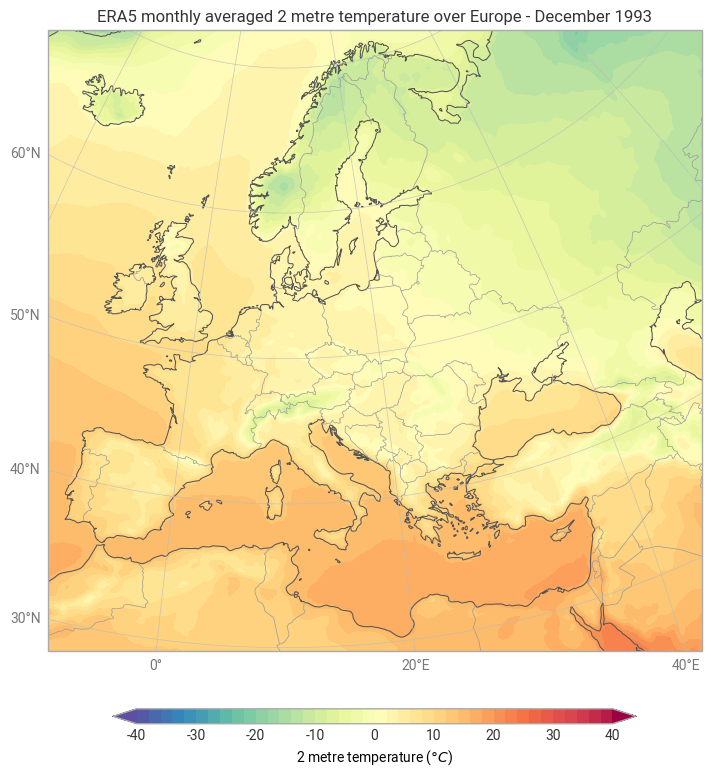

In [1]:
# Import earthkit-data for accessing sample datasets
import earthkit.data as ekd

# Import earthkit-plots to visualise them
import earthkit.plots as ekp

# Download some sample data - ERA5 monthly averaged temperature
era5_2t = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib")

# Create a map showing a sub-domain over Europe
chart = ekp.Map(domain="Europe")

# Do a filled contour plot, with units converted to celsius and an automatic style
chart.contourf(era5_2t, units="celsius", style="auto")

# Add a title with metadata formatting
chart.title("ERA5 monthly averaged {variable_name} over {domain} - {time:%B %Y}")

# Add map decorations
chart.coastlines()
chart.borders()
chart.gridlines()

# Add a legend
chart.legend(label="{variable_name} ({units})")

chart.show()

Let's explore what each step does.

```python
# Import earthkit-data for accessing sample datasets
import earthkit.data as ekd

# Import earthkit-plots to visualise them
import earthkit.plots as ekp
```

The [earthkit ecosystem](https://earthkit.ecmwf.int/) provides tools for accessing, processing and visualising weather and climate datasets. For this example, we need earthkit-data to get some sample data, and earthkit-plots to plot it. No other libraries need to be imported.

```python
# Download some sample data - ERA5 monthly averaged temperature
era5_2t = ekd.from_source("sample", "era5-monthly-mean-2t-199312.grib")
```

Here we load a sample GRIB file containing ERA5 monthly averaged 2-metre temperature for December 1993. **earthkit-data** handles accessing and decoding the remote dataset and provides a consistent interface regardless of the underlying format.

> 📖 For comprehensive documentation about accessing various data sources with earthkit-data, see the [earthkit-data documentation](https://earthkit-data.readthedocs.io/en/latest/examples/index.html).

```python
# Create a map showing a sub-domain over Europe
chart = ekp.Map(domain="Europe")
```

This creates a new map canvas. By passing `domain="Europe"`, we use one of earthkit-plots' built-in named domains. Under-the-hood, earthkit-plots automatically selects an appropriate map projection for the given domain.

You can also:
- Pass a country name, e.g. `domain="France"`.
- Pass a bounding box as `[lon_min, lon_max, lat_min, lat_max]`.
- Include a `crs` argument, passing a [cartopy coordinate system](https://cartopy.readthedocs.io/stable/reference/projections.html#cartopy-projections) to control the map projection.
- Omit the argument entirely, in which case the extent and CRS is inferred from your data.

```python
# Do a filled contour plot, with units converted to celsius and an automatic style
chart.contourf(era5_2t, units="celsius", style="auto")
```

earthkit-plots augments matplotlib's standard plotting methods (such as `contourf`, `pcolormesh`, `scatter`) with extra functionality:

- **`units="celsius"`** converts the data from its native units (Kelvin) to Celsius at plot time, with no need to modify the underlying data.
- **`style="auto"`** — selects a pre-defined colour scheme appropriate for the variable being plotted.

Any additional keyword arguments supported by matplotlib's [contourf](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.contourf.html) can be passed here too.

```python
# Add a title with metadata formatting
chart.title("ERA5 monthly averaged {variable_name} over {domain} - {time:%B %Y}")
```

earthkit-plots supports **metadata-aware format strings** in titles and labels. These curly-brace placeholders are automatically populated from your dataset's metadata.

This works with GRIB keys, CF-conventions, and simple xarray attributes. You can make use of protected magic strings to avoid having to adapt titles to different metadata formats - for example:
- The `{variable_name}` key tries to find a human-readable variable name (checks `long_name`, `standard_name`, `short_name`, and GRIB keys in priority order).
- The `{domain}` key adapts to the selected named map domain.
- The `{time}` key searches for well-established time-related metadata structures whatever format your input data comes from. You can also use format specs to format the time into a format of your choice with Python's standard [strftime formats](https://docs.python.org/3/library/datetime.html#strftime-and-strptime-format-codes).

```python
# Add map decorations
chart.coastlines()
chart.borders()
chart.gridlines()
```

These convenience methods are based on cartopy's methods like [coastlines](https://cartopy.readthedocs.io/stable/reference/generated/cartopy.mpl.geoaxes.GeoAxes.html#cartopy.mpl.geoaxes.GeoAxes.coastlines) and [gridlines](https://cartopy.readthedocs.io/stable/reference/generated/cartopy.mpl.geoaxes.GeoAxes.html#cartopy.mpl.geoaxes.GeoAxes.gridlines). Additional methods like `borders`, `administrative_regions` and more are included in earthkit-plots for convenience.

```python
# Add a legend
chart.legend(label="{variable_name} ({units})")
```

The `legend` method in earthkit-plots unifies matplotlib's `colorbar` and `legend` into a single call. It adds a legend for every plotted layer, styled appropriately. The `label` argument supports the same metadata format strings as the title - here `{units}` resolves to the units that were passed to `contourf` (or the data's original units if none were specified).

Putting it all together, the complete imperative script looks like this:

```python
chart = ekp.Map(domain="Europe")
chart.contourf(era5_2t, units="celsius", style="auto")
chart.title("ERA5 monthly averaged {variable_name} over {domain} - {time:%B %Y}")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.legend(label="{variable_name} ({units})")
chart.show()
```

Finally, we show the plot. This is a simple wrapper around `plt.show()` for convenience (you can use either interchangeably, or omit it altogether if you are in a Jupyter notebook).

### Customising plots

This first example has demonstrated how to make use of the high-level, automatic features of earthkit-plots to quickly visualise your data. But what if you want to customise the plot? How would you use a different map projection, colour scheme or levels?

Since earthkit-plots is underpinned by matplotlib and cartopy, we can make use of those libraries - matplotlib for styling, cartopy for [map projections](https://cartopy.readthedocs.io/stable/reference/projections.html#cartopy-projections) - to customise our plot.

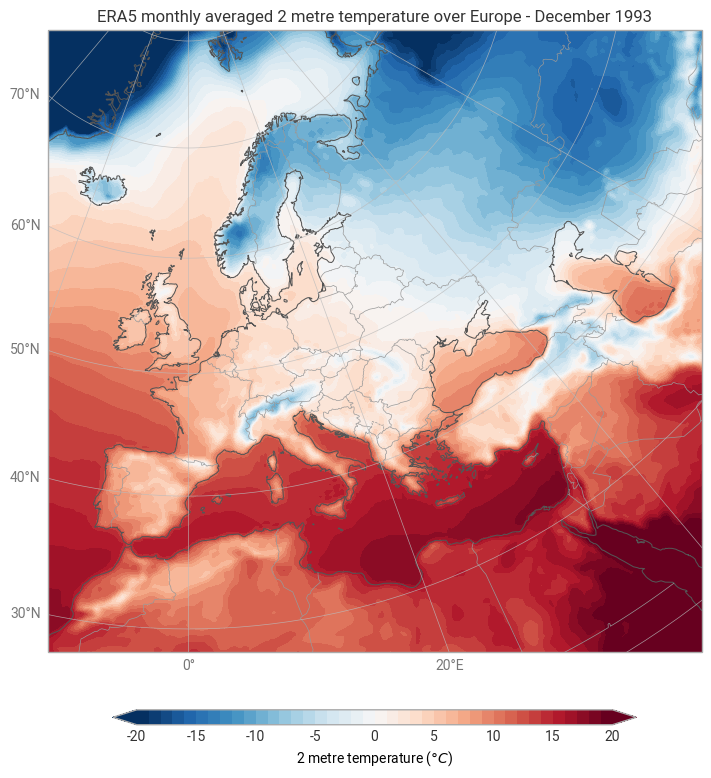

In [2]:
# Import cartopy's coordinate systems
import cartopy.crs as ccrs

chart = ekp.Map(domain="Europe", crs=ccrs.NorthPolarStereo())
chart.contourf(era5_2t, units="celsius", cmap="RdBu_r", levels=range(-20, 21), extend="both")
chart.title("ERA5 monthly averaged {variable_name} over {domain} - {time:%B %Y}")
chart.coastlines()
chart.borders()
chart.gridlines()
chart.legend()
chart.title("ERA5 monthly averaged {variable_name} over {domain} - {time:%B %Y}")
chart.show()

### An even higher-level API

As well as the flexible and high-level object-oriented interface described above, earthkit-plots also provides super high-level shortcut functions that handle most of the plotting workflow for you.

This level of API can help you quickly visualise your data without having to give it too much thought, with automatic titles, legend and coastlines (for map plots) included by default.

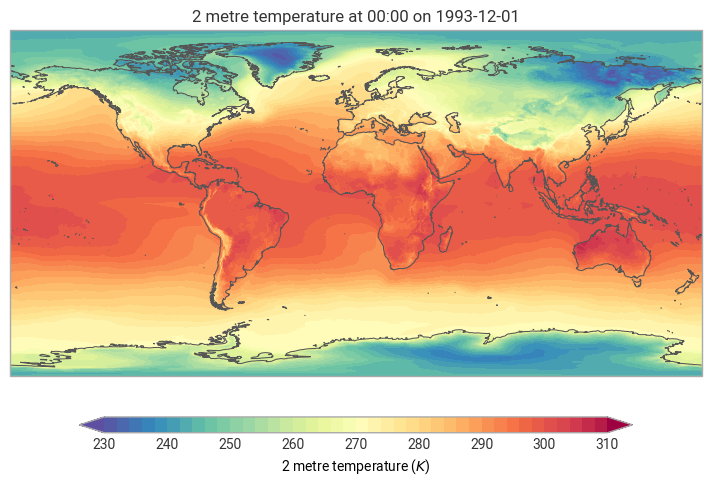

In [3]:
ekp.geo.plot(era5_2t)

These high-level methods accept some basic configuration arguments like `domain` and `units` - plus they gain the convenience of being **fully chainable** with plotting methods - that is, you can call additional plotting methods on the result, and on the result of that, etc.

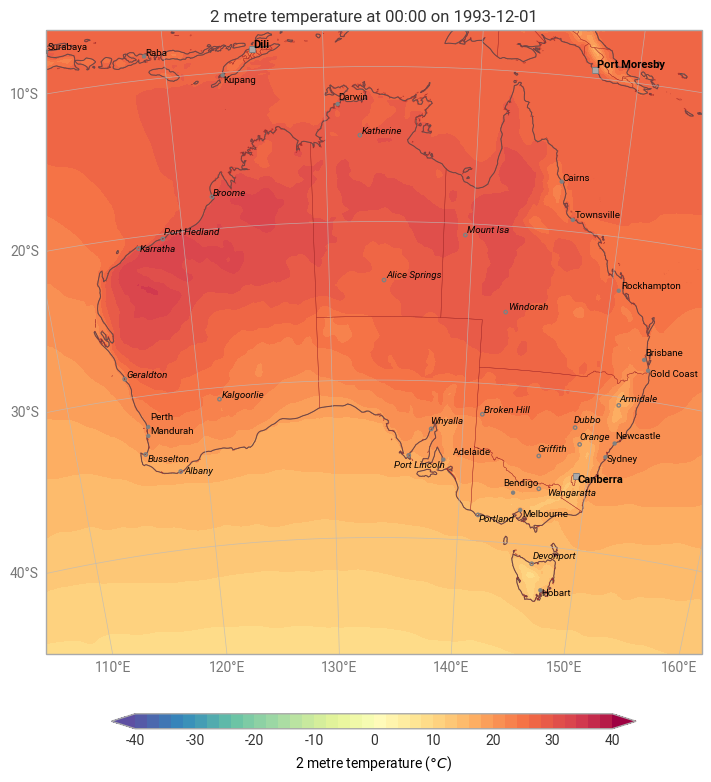

In [4]:
(
    ekp.geo.plot(era5_2t, units="celsius", domain="Australia")
    .administrative_areas(color="brown")
    .gridlines(xstep=10, ystep=10)
    .cities(adjust_labels=True)
)

### Non-map plots

earthkit-plots is able to capitalise on its rich understanding of common metadata standards and data abstractions to also provide benefits to non-map plots.

#### Time series



In [5]:
era5_reading_timeseries = ekd.from_source("sample", "era5-reading-timeseries.nc").to_xarray()
era5_reading_timeseries

<xarray.Dataset> Size: 1kB
Dimensions:     (valid_time: 96)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 768B 2025-08-20 ... 2025-08-23T23...
    latitude    float64 8B ...
    longitude   float64 8B ...
Data variables:
    t2m         (valid_time) float32 384B dask.array<chunksize=(96,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

We can plot this data in much the same way as we plot map plots - by passing the data into `ekp.timeseries.line`. We still benefit from:

- Unit conversion (`units="celsius"`)
- Metadata formatting in the title
- Automatic x and y extraction, with no need to pass dimension names to earthkit-plots
- High-level tick formatting, making it quick and easy to show daily ticks labelled in the centre

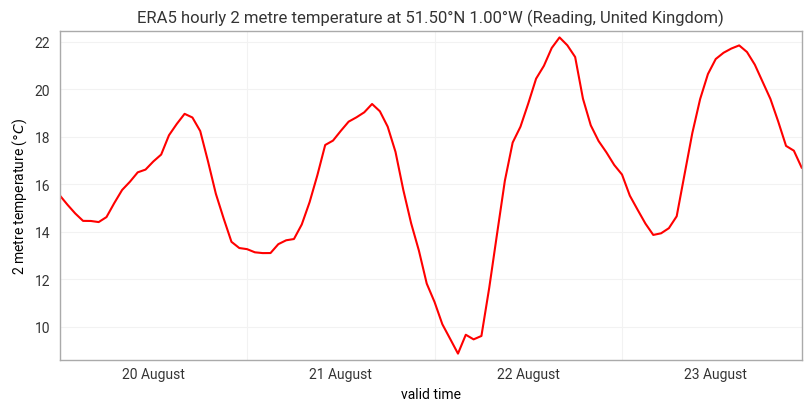

In [6]:
( ekp.timeseries.line(
    era5_reading_timeseries,
    color="red",
    units="celsius",
)
.title(
    "ERA5 hourly {variable_name} at {latitude:%Lt} {longitude:%Ln} "
    "({location:%c}, {location:%C})"
).xticks(
    frequency="D",
    format="%d %B",
    period=True,
)
)

### Relationship to matplotlib and cartopy

earthkit-plots is built on top of the popular and powerful visualisation libraries matplotlib and cartopy. Whenever you use a method in earthkit-plots like `contourf`, you can pass anything that [matplotlib's contourf accepts](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.contourf.html).

Many matplotlib and cartopy methods have a high-level implementation on earthkit-plots classes, but sometimes it's useful to make use of the **escape hatches** `.ax` and `.fig` to access the underlying matplotlib axes and figure objects.